In [2]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# ==========================================================
# Load Feature Datasets
# ==========================================================

sales_df = pd.read_csv("../data/features/sales_features.csv")
calendar_df = pd.read_csv("../data/features/calendar_features.csv")
prices_df = pd.read_csv("../data/features/prices_features.csv")

calendar_df["date"] = pd.to_datetime(calendar_df["date"])

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [4]:
print("Sales Shape :", sales_df.shape)
print("Calendar Shape :", calendar_df.shape)
print("Prices Shape :", prices_df.shape)

Sales Shape : (30490, 1919)
Calendar Shape : (1969, 21)
Prices Shape : (6841121, 4)


In [5]:
sales_clean = sales_df.copy()

print("Backup created successfully!")

Backup created successfully!


In [6]:
sales_clean.head()

id        item_id    dept_id   cat_id store_id state_id  d_1  d_2  d_3  d_4  d_5  d_6  d_7  d_8  d_9  d_10  d_11  d_12  d_13  d_14  d_15  d_16  d_17  d_18  d_19  d_20  d_21  d_22  d_23  d_24  d_25  d_26  d_27  d_28  d_29  d_30  d_31  d_32  d_33  d_34  d_35  d_36  d_37  d_38  d_39  d_40  d_41  d_42  d_43  d_44  d_45  d_46  d_47  d_48  d_49  d_50  d_51  d_52  d_53  d_54  d_55  d_56  d_57  d_58  d_59  d_60  d_61  d_62  d_63  d_64  d_65  d_66  d_67  d_68  d_69  d_70  d_71  d_72  d_73  d_74  d_75  d_76  d_77  d_78  d_79  d_80  d_81  d_82  d_83  d_84  d_85  d_86  d_87  d_88  d_89  d_90  d_91  d_92  d_93  d_94  d_95  d_96  d_97  d_98  d_99  d_100  d_101  d_102  d_103  d_104  d_105  d_106  d_107  d_108  d_109  d_110  d_111  d_112  d_113  d_114  d_115  d_116  d_117  d_118  d_119  d_120  d_121  d_122  d_123  d_124  d_125  d_126  d_127  d_128  d_129  d_130  d_131  d_132  d_133  d_134  d_135  d_136  d_137  d_138  d_139  d_140  d_141  d_142  d_143  d_144  d_145  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1       CA    0    0    0    0    0    0    0    0    0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1       CA    0    0    0    0    0    0    0    0    0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      1      0   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1       CA    0    0    0    0    0    0    0    0    0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0   
3  HOBBIES_1_004_CA_1_validation  HOBBIES_1_00

In [7]:
sales_columns = [col for col in sales_clean.columns if col.startswith("d_")]

print("Number of Daily Sales Columns:", len(sales_columns))

Number of Daily Sales Columns: 1913


In [8]:
memory = sales_clean.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Memory Usage: {memory:.2f} MB")

Memory Usage: 456.78 MB


In [9]:
sales_clean[sales_columns].min().min()

np.int64(0)

In [10]:
sales_clean[sales_columns].max().max()

np.int64(763)

In [11]:
(sales_clean[sales_columns].sum(axis=1) == 0).sum()

np.int64(0)

In [12]:
sales_clean[sales_columns].mean().mean()

np.float64(1.126322153733316)

In [13]:
sales_clean.to_csv("../data/processed/clean_sales.csv", index=False)

print("Sales dataset saved successfully!")

Sales dataset saved successfully!


In [14]:
sales_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), object(6)
memory usage: 456.8 MB


In [15]:
sales_df.columns[:10]

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4'], dtype='object')

In [16]:
sales_clean["total_sales"] = sales_clean[sales_columns].sum(axis=1)

sales_clean[["item_id", "total_sales"]].head()

,item_id,total_sales
0,HOBBIES_1_001,600
1,HOBBIES_1_002,493
2,HOBBIES_1_003,288
3,HOBBIES_1_004,3288
4,HOBBIES_1_005,1849


In [17]:
sales_clean[["item_id", "total_sales"]].sort_values(
    by="total_sales",
    ascending=False
).head(10)

,item_id,total_sales
8412,FOODS_3_090,250502
18055,FOODS_3_586,192835
21104,FOODS_3_586,150122
8908,FOODS_3_586,134386
2314,FOODS_3_090,127203
29755,FOODS_3_090,121434
17559,FOODS_3_090,119496
20608,FOODS_3_090,114854
17721,FOODS_3_252,114153
15006,FOODS_3_586,112454


In [18]:
sales_df.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4',
       ...
       'd_1904', 'd_1905', 'd_1906', 'd_1907', 'd_1908', 'd_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913'], dtype='object', length=1919)

In [19]:
# Create Total Sales column
sales_df["total_sales"] = sales_df.loc[:, "d_1":"d_1913"].sum(axis=1)

In [20]:
sales_df[["item_id", "total_sales"]].head()

,item_id,total_sales
0,HOBBIES_1_001,600
1,HOBBIES_1_002,493
2,HOBBIES_1_003,288
3,HOBBIES_1_004,3288
4,HOBBIES_1_005,1849


In [21]:
# Total Sales by Category

category_sales = (
    sales_df.groupby("cat_id")["total_sales"]
    .sum()
    .reset_index()
    .sort_values(by="total_sales", ascending=False)
)

category_sales

,cat_id,total_sales
0,FOODS,45089939
2,HOUSEHOLD,14480670
1,HOBBIES,6124800


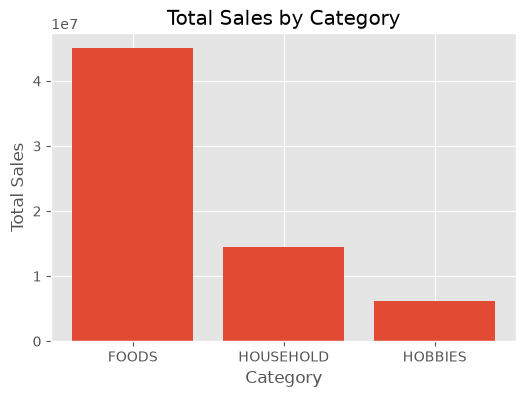

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(category_sales["cat_id"], category_sales["total_sales"])

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [23]:
# ==========================================================
# Total Sales by Department
# ==========================================================

department_sales = (
    sales_df.groupby("dept_id")["total_sales"]
    .sum()
    .reset_index()
    .sort_values(by="total_sales", ascending=False)
)

department_sales

,dept_id,total_sales
2,FOODS_3,32372076
5,HOUSEHOLD_1,11500526
1,FOODS_2,7629822
3,HOBBIES_1,5596460
0,FOODS_1,5088041
6,HOUSEHOLD_2,2980144
4,HOBBIES_2,528340


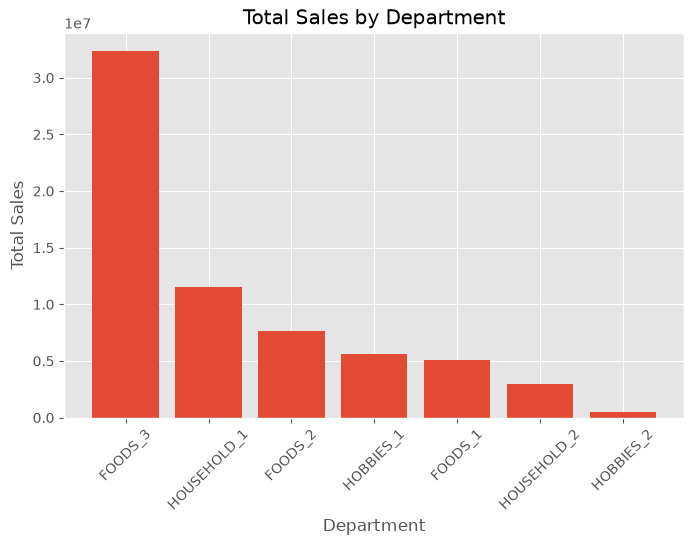

In [24]:
# ==========================================================
# Department-wise Total Sales
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(department_sales["dept_id"], department_sales["total_sales"])

plt.title("Total Sales by Department")
plt.xlabel("Department")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

In [25]:
# ==========================================================
# Total Sales by Store
# ==========================================================

store_sales = (
    sales_df.groupby("store_id")["total_sales"]
    .sum()
    .reset_index()
    .sort_values(by="total_sales", ascending=False)
)

store_sales

,store_id,total_sales
2,CA_3,11188180
0,CA_1,7698216
5,TX_2,7214384
8,WI_2,6544012
9,WI_3,6427782
6,TX_3,6089330
1,CA_2,5685475
4,TX_1,5595292
7,WI_1,5149062
3,CA_4,4103676


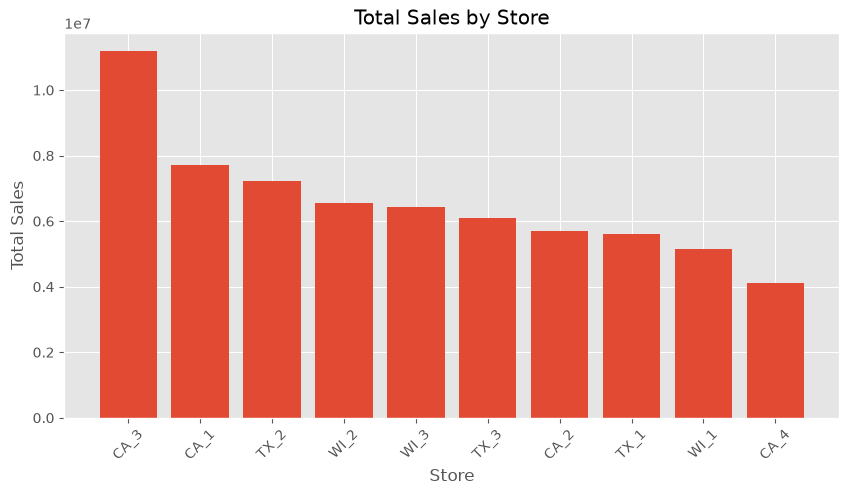

In [26]:
# ==========================================================
# Total Sales by Store
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(store_sales["store_id"], store_sales["total_sales"])

plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

In [27]:
sales_df[sales_df["state_id"] == "WI"][["store_id", "total_sales"]].groupby("store_id").sum()

,total_sales
store_id,
WI_1,5149062
WI_2,6544012
WI_3,6427782


In [33]:
print(state_sales)

NameError: name 'state_sales' is not defined

In [34]:
# ==========================================================
# Total Sales by State
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(state_sales["state_id"], state_sales["total_sales"])

plt.title("Total Sales by State")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.show()

NameError: name 'state_sales' is not defined

<Figure size 600x400 with 0 Axes>

In [35]:
# ==========================================================
# Daily Total Sales
# ==========================================================

daily_sales = sales_df.loc[:, "d_1":"d_1913"].sum(axis=0)

daily_sales.head()

d_1    32631
d_2    31749
d_3    23783
d_4    25412
d_5    19146
dtype: int64

In [36]:
# ==========================================================
# Create Daily Sales DataFrame
# ==========================================================

daily_sales_df = pd.DataFrame({
    "d": daily_sales.index,
    "total_sales": daily_sales.values
})

daily_sales_df.head()

,d,total_sales
0,d_1,32631
1,d_2,31749
2,d_3,23783
3,d_4,25412
4,d_5,19146


In [37]:
# ==========================================================
# Merge Daily Sales with Calendar
# ==========================================================

daily_sales_df = daily_sales_df.merge(
    calendar_df,
    on="d",
    how="left"
)

daily_sales_df.head()

,d,total_sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,day,month_name,quarter,week,is_weekend,has_event,snap_active
0,d_1,32631,2011-01-29,11101,Saturday,1,1,2011,No_Event,No_Event,No_Event,No_Event,0,0,0,29,January,1,4,1,0,0
1,d_2,31749,2011-01-30,11101,Sunday,2,1,2011,No_Event,No_Event,No_Event,No_Event,0,0,0,30,January,1,4,1,0,0
2,d_3,23783,2011-01-31,11101,Monday,3,1,2011,No_Event,No_Event,No_Event,No_Event,0,0,0,31,January,1,5,0,0,0
3,d_4,25412,2011-02-01,11101,Tuesday,4,2,2011,No_Event,No_Event,No_Event,No_Event,1,1,0,1,February,1,5,0,0,1
4,d_5,19146,2011-02-02,11101,Wednesday,5,2,2011,No_Event,No_Event,No_Event,No_Event,1,0,1,2,February,1,5,0,0,1


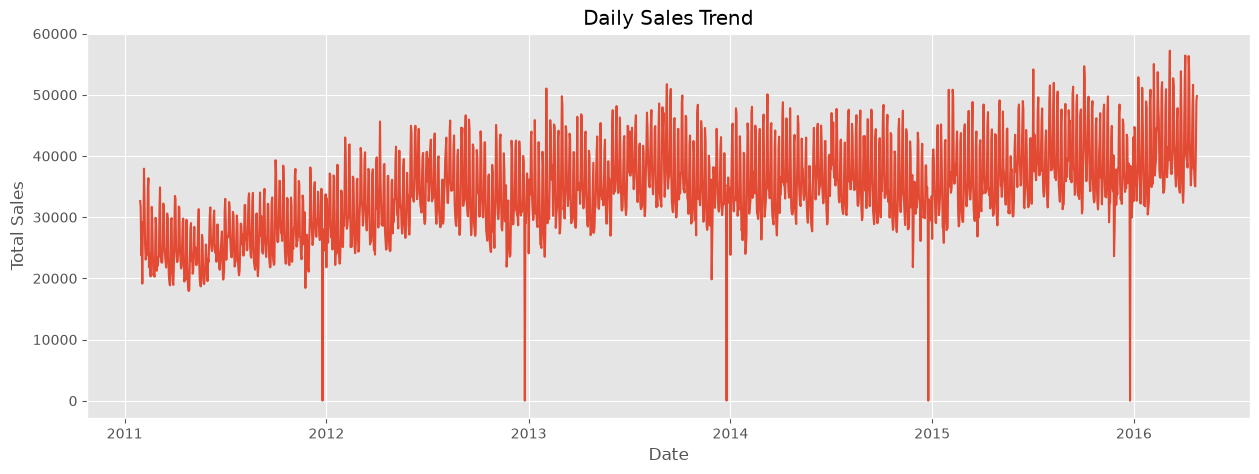

In [38]:
# ==========================================================
# Daily Sales Trend
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    daily_sales_df["date"],
    daily_sales_df["total_sales"]
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

In [39]:
# ==========================================================
# Average Sales by Month
# ==========================================================

monthly_sales = (
    daily_sales_df
    .groupby("month")["total_sales"]
    .mean()
    .reset_index()
)

monthly_sales

,month,total_sales
0,1,33832.348101
1,2,34644.641176
2,3,34339.838710
3,4,34258.683908
4,5,32503.851613
5,6,35001.413333
6,7,35122.419355
7,8,35946.645161
8,9,35479.260000
9,10,34713.477419


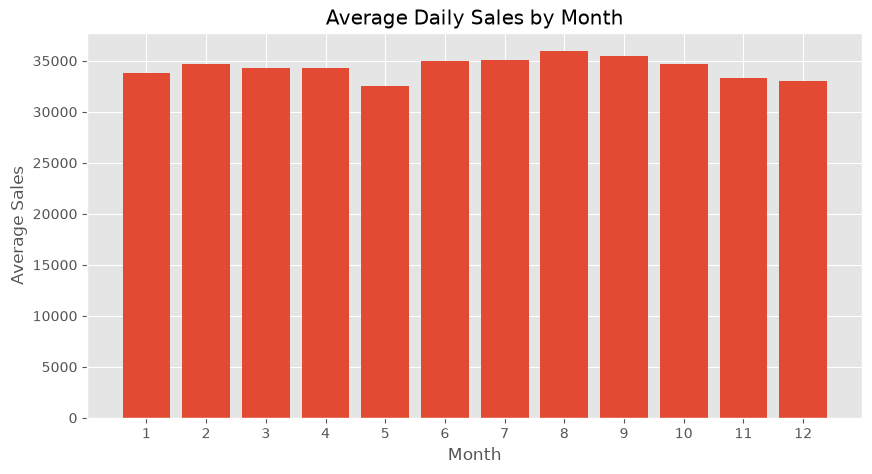

In [40]:
# ==========================================================
# Average Sales by Month
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    monthly_sales["month"],
    monthly_sales["total_sales"]
)

plt.title("Average Daily Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(range(1,13))

plt.show()

In [41]:
# ==========================================================
# Average Sales by Weekday
# ==========================================================

weekday_sales = (
    daily_sales_df
    .groupby("weekday")["total_sales"]
    .mean()
    .reset_index()
)

weekday_sales

,weekday,total_sales
0,Friday,34225.985348
1,Monday,32852.967033
2,Saturday,41546.894161
3,Sunday,41130.021898
4,Thursday,30205.007326
5,Tuesday,30368.780220
6,Wednesday,30010.021978


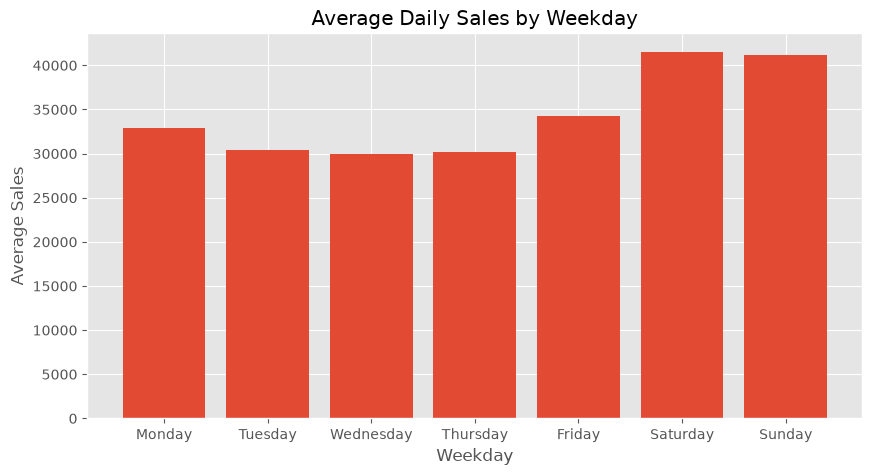

In [42]:
# ==========================================================
# Average Sales by Weekday
# ==========================================================

import matplotlib.pyplot as plt

# Arrange weekdays in order
order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_sales["weekday"] = pd.Categorical(
    weekday_sales["weekday"],
    categories=order,
    ordered=True
)

weekday_sales = weekday_sales.sort_values("weekday")

plt.figure(figsize=(10,5))

plt.bar(
    weekday_sales["weekday"],
    weekday_sales["total_sales"]
)

plt.title("Average Daily Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Sales")

plt.show()

In [43]:
# ==========================================================
# Average Sales: Event vs Non-Event Days
# ==========================================================

event_sales = (
    daily_sales_df
    .groupby("has_event")["total_sales"]
    .mean()
    .reset_index()
)

event_sales["has_event"] = event_sales["has_event"].map({
    0: "No Event",
    1: "Event"
})

event_sales

,has_event,total_sales
0,No Event,34489.207504
1,Event,32655.149351


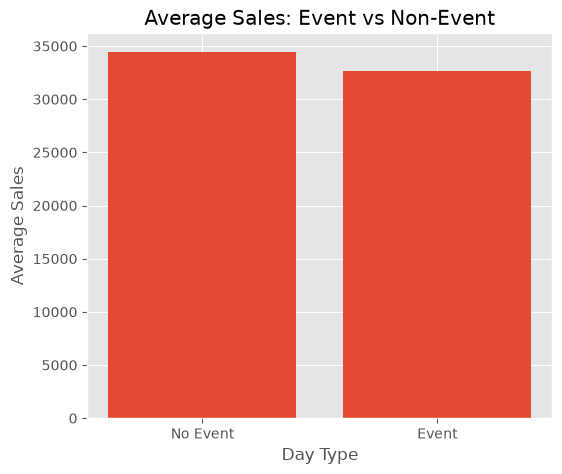

In [44]:
# ==========================================================
# Event vs Non-Event Sales
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    event_sales["has_event"],
    event_sales["total_sales"]
)

plt.title("Average Sales: Event vs Non-Event")
plt.xlabel("Day Type")
plt.ylabel("Average Sales")

plt.show()

In [45]:
# ==========================================================
# Top 10 Best-Selling Products
# ==========================================================

top_products = (
    sales_df
    .groupby("item_id")["total_sales"]
    .sum()
    .reset_index()
    .sort_values(by="total_sales", ascending=False)
    .head(10)
)

top_products

,item_id,total_sales
702,FOODS_3_090,1002529
1198,FOODS_3_586,920242
864,FOODS_3_252,565299
1167,FOODS_3_555,491287
1325,FOODS_3_714,396172
1199,FOODS_3_587,396119
1306,FOODS_3_694,390001
838,FOODS_3_226,363082
814,FOODS_3_202,295689
1334,FOODS_3_723,284333


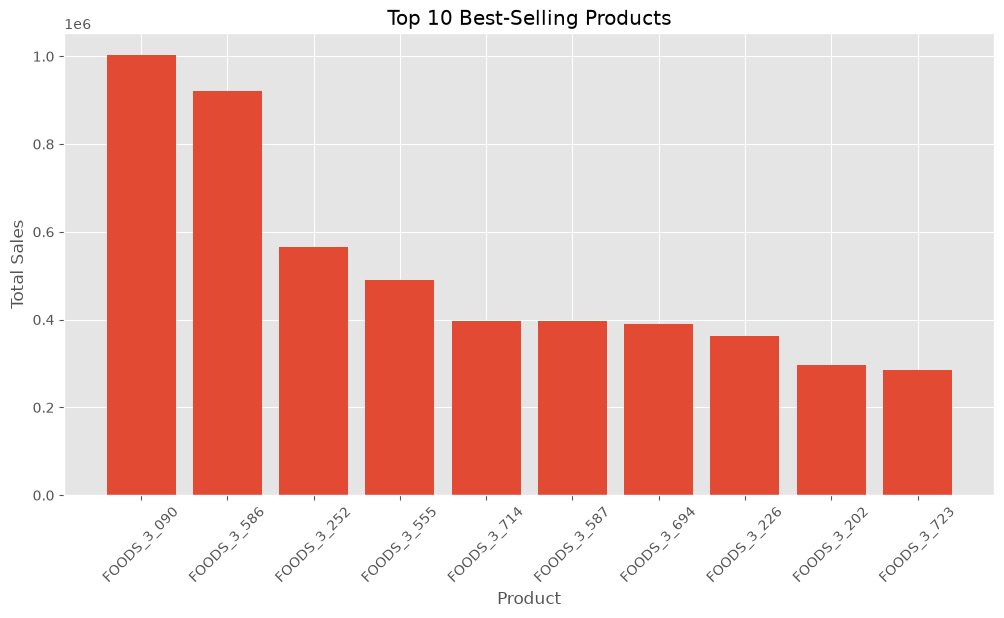

In [46]:
# ==========================================================
# Top 10 Best-Selling Products
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top_products["item_id"],
    top_products["total_sales"]
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

In [47]:
# ==========================================================
# Top 10 Least-Selling Products
# ==========================================================

least_products = (
    sales_df
    .groupby("item_id")["total_sales"]
    .sum()
    .reset_index()
    .sort_values(by="total_sales", ascending=True)
    .head(10)
)

least_products

,item_id,total_sales
2634,HOUSEHOLD_2_101,568
1971,HOBBIES_2_119,660
2708,HOUSEHOLD_2_175,718
1936,HOBBIES_2_084,746
2538,HOUSEHOLD_2_005,757
1963,HOBBIES_2_111,770
2777,HOUSEHOLD_2_245,780
2663,HOUSEHOLD_2_130,789
2839,HOUSEHOLD_2_307,796
1875,HOBBIES_2_023,800


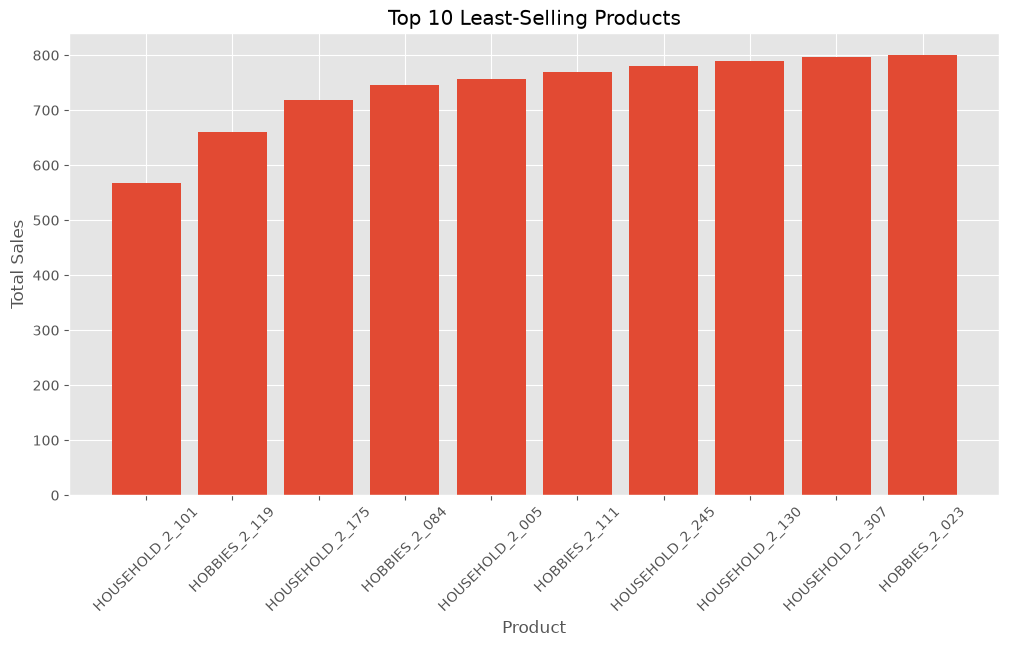

In [48]:
# ==========================================================
# Top 10 Least-Selling Products
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    least_products["item_id"],
    least_products["total_sales"]
)

plt.title("Top 10 Least-Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

In [49]:
# ==========================================================
# Basic Statistics of Selling Price
# ==========================================================

prices_df["sell_price"].describe()

count    6.841121e+06
mean     4.410952e+00
std      3.408814e+00
min      1.000000e-02
25%      2.180000e+00
50%      3.470000e+00
75%      5.840000e+00
max      1.073200e+02
Name: sell_price, dtype: float64

In [50]:
# ==========================================================
# Top 10 Most Expensive Products
# ==========================================================

top_prices = (
    prices_df
    .sort_values("sell_price", ascending=False)
    [["item_id", "store_id", "sell_price"]]
    .drop_duplicates()
    .head(10)
)

top_prices

,item_id,store_id,sell_price
6485947,HOUSEHOLD_2_406,WI_3,107.32
5805276,HOUSEHOLD_2_406,WI_2,61.46
3065026,HOUSEHOLD_2_466,TX_1,52.62
3065102,HOUSEHOLD_2_466,TX_1,48.78
3065156,HOUSEHOLD_2_466,TX_1,45.32
3065144,HOUSEHOLD_2_466,TX_1,44.88
3065039,HOUSEHOLD_2_466,TX_1,44.84
2996474,HOUSEHOLD_2_178,TX_1,44.36
5805240,HOUSEHOLD_2_406,WI_2,43.99
3065011,HOUSEHOLD_2_466,TX_1,43.84


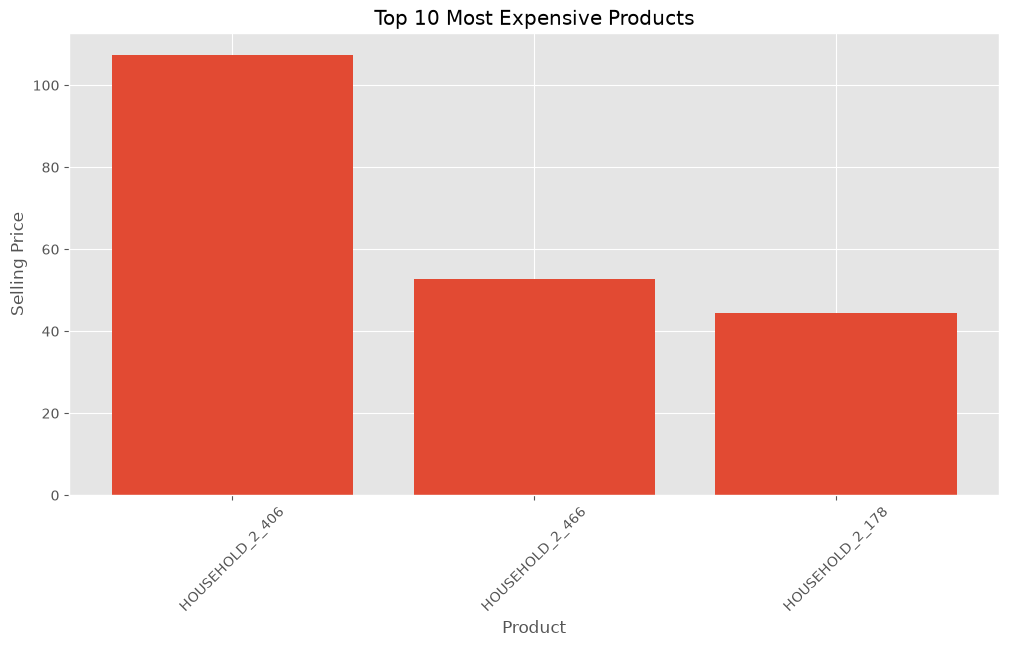

In [51]:
# ==========================================================
# Top 10 Most Expensive Products
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top_prices["item_id"],
    top_prices["sell_price"]
)

plt.title("Top 10 Most Expensive Products")
plt.xlabel("Product")
plt.ylabel("Selling Price")

plt.xticks(rotation=45)

plt.show()

In [52]:
# ==========================================================
# Top 10 Cheapest Products
# ==========================================================

cheapest_products = (
    prices_df
    .sort_values("sell_price")
    [["item_id", "store_id", "sell_price"]]
    .drop_duplicates()
    .head(10)
)

cheapest_products

,item_id,store_id,sell_price
6282349,HOUSEHOLD_1_036,WI_3,0.01
5316537,FOODS_3_122,WI_1,0.01
1394086,HOBBIES_1_261,CA_3,0.01
2617306,FOODS_3_413,CA_4,0.01
225727,HOUSEHOLD_1_443,CA_1,0.01
5044267,HOUSEHOLD_1_533,WI_1,0.01
4877375,HOBBIES_1_338,WI_1,0.01
4728843,FOODS_3_498,TX_3,0.02
4708579,FOODS_3_410,TX_3,0.02
4210558,HOBBIES_2_021,TX_3,0.05


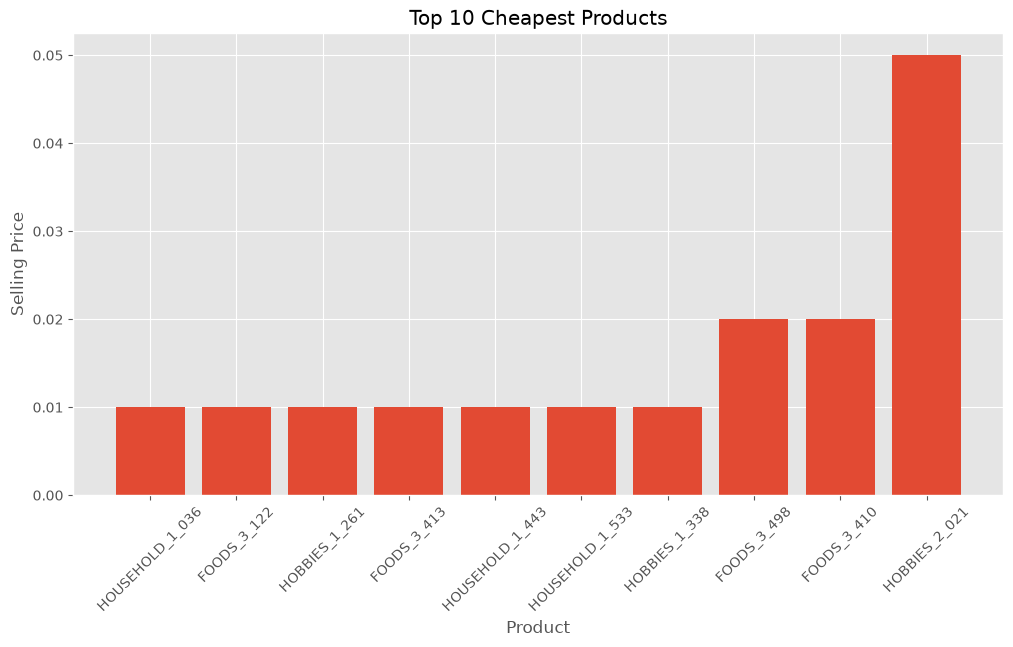

In [53]:
# ==========================================================
# Top 10 Cheapest Products
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    cheapest_products["item_id"],
    cheapest_products["sell_price"]
)

plt.title("Top 10 Cheapest Products")
plt.xlabel("Product")
plt.ylabel("Selling Price")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# ==========================================================
# Average Selling Price by Week
# ==========================================================

weekly_price = (
    prices_df
    .groupby("wm_yr_wk")["sell_price"]
    .mean()
    .reset_index()
)

weekly_price.head()

,wm_yr_wk,sell_price
0,11101,4.071247
1,11102,4.161574
2,11103,4.190454
3,11104,4.200812
4,11105,4.202976


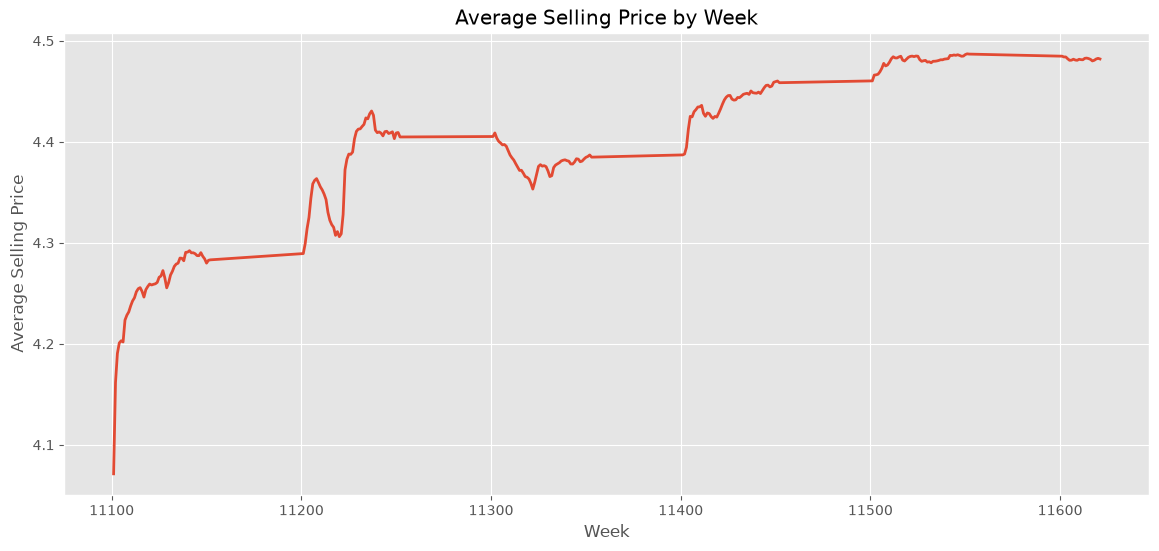

In [ ]:
# ==========================================================
# Weekly Average Selling Price Trend
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    weekly_price["wm_yr_wk"],
    weekly_price["sell_price"],
    linewidth=2
)

plt.title("Average Selling Price by Week")
plt.xlabel("Week")
plt.ylabel("Average Selling Price")

plt.grid(True)

plt.show()

In [ ]:
# ==========================================================
# Average Selling Price by Store
# ==========================================================

store_price = (
    prices_df
    .groupby("store_id")["sell_price"]
    .mean()
    .reset_index()
    .sort_values(by="sell_price", ascending=False)
)

store_price

,store_id,sell_price
7,WI_1,4.457712
1,CA_2,4.445500
8,WI_2,4.441717
3,CA_4,4.421580
9,WI_3,4.418117
0,CA_1,4.414233
2,CA_3,4.388229
6,TX_3,4.387365
4,TX_1,4.374569
5,TX_2,4.366766


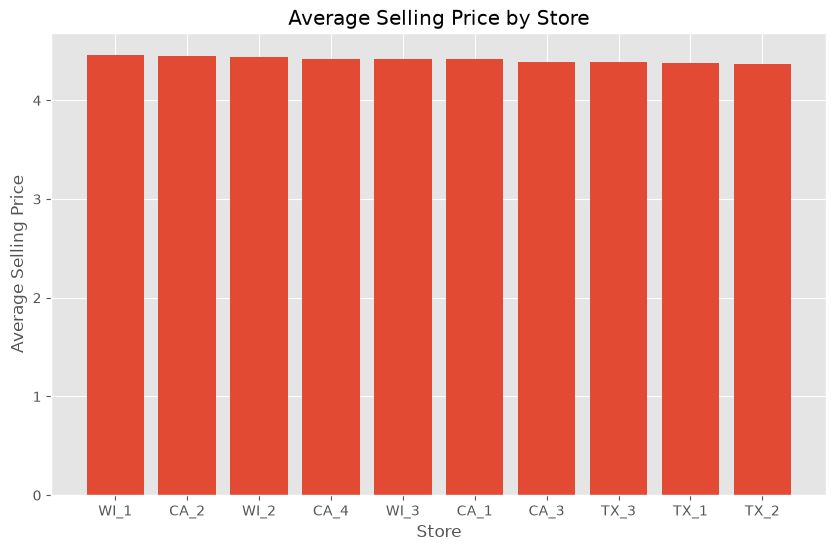

In [ ]:
# ==========================================================
# Average Selling Price by Store
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    store_price["store_id"],
    store_price["sell_price"]
)

plt.title("Average Selling Price by Store")
plt.xlabel("Store")
plt.ylabel("Average Selling Price")

plt.show()

In [ ]:
# ==========================================================
# Average Selling Price by Category
# ==========================================================

# Merge sales metadata with prices
price_category = prices_df.merge(
    sales_df[["item_id", "cat_id"]].drop_duplicates(),
    on="item_id",
    how="left"
)

category_price = (
    price_category
    .groupby("cat_id")["sell_price"]
    .mean()
    .reset_index()
    .sort_values(by="sell_price", ascending=False)
)

category_price

,cat_id,sell_price
2,HOUSEHOLD,5.465780
1,HOBBIES,5.333896
0,FOODS,3.251027


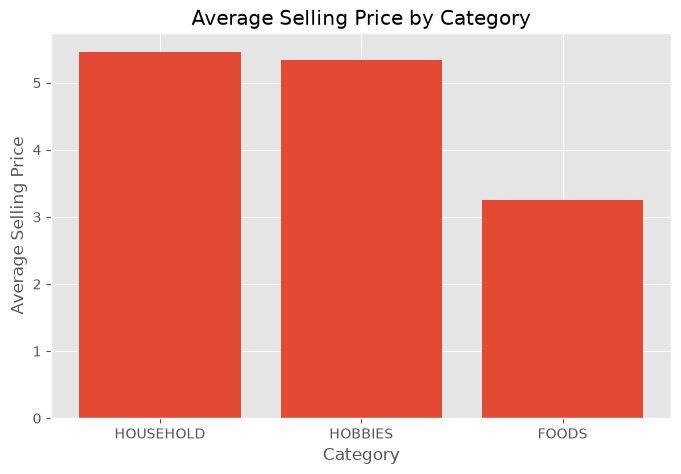

In [ ]:
# ==========================================================
# Average Selling Price by Category
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    category_price["cat_id"],
    category_price["sell_price"]
)

plt.title("Average Selling Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Selling Price")

plt.show()

In [ ]:
# ==========================================================
# Average Selling Price by Department
# ==========================================================

price_department = prices_df.merge(
    sales_df[["item_id", "dept_id"]].drop_duplicates(),
    on="item_id",
    how="left"
)

department_price = (
    price_department
    .groupby("dept_id")["sell_price"]
    .mean()
    .reset_index()
    .sort_values(by="sell_price", ascending=False)
)

department_price

,dept_id,sell_price
3,HOBBIES_1,6.225784
6,HOUSEHOLD_2,5.855558
5,HOUSEHOLD_1,5.057583
1,FOODS_2,4.084008
0,FOODS_1,3.374649
2,FOODS_3,2.842107
4,HOBBIES_2,2.686807


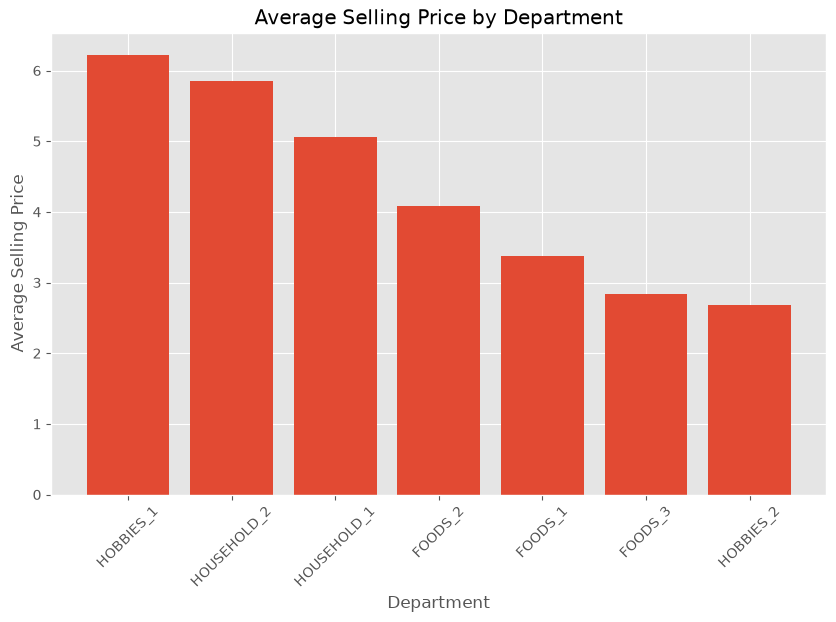

In [ ]:
# ==========================================================
# Average Selling Price by Department
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    department_price["dept_id"],
    department_price["sell_price"]
)

plt.title("Average Selling Price by Department")
plt.xlabel("Department")
plt.ylabel("Average Selling Price")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# ==========================================================
# Average Daily Sales by Store
# ==========================================================

daily_cols = [col for col in sales_df.columns if col.startswith("d_")]

store_daily_sales = (
    sales_df
    .groupby("store_id")[daily_cols]
    .sum()
    .mean(axis=1)
    .reset_index(name="avg_daily_sales")
    .sort_values(by="avg_daily_sales", ascending=False)
)

store_daily_sales

,store_id,avg_daily_sales
2,CA_3,5848.499739
0,CA_1,4024.158913
5,TX_2,3771.240983
8,WI_2,3420.811291
9,WI_3,3360.053319
6,TX_3,3183.131208
1,CA_2,2972.020387
4,TX_1,2924.878202
7,WI_1,2691.616309
3,CA_4,2145.152117


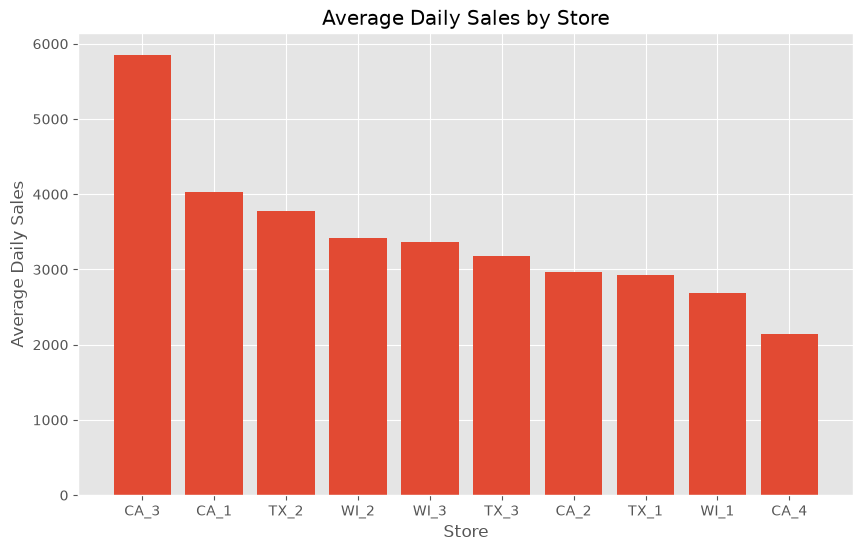

In [ ]:
# ==========================================================
# Average Daily Sales by Store
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    store_daily_sales["store_id"],
    store_daily_sales["avg_daily_sales"]
)

plt.title("Average Daily Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Daily Sales")

plt.show()

In [54]:
top_products = sales_clean[
    ["item_id", "total_sales"]
].sort_values(
    by="total_sales",
    ascending=False
).head(10)

top_products

,item_id,total_sales
8412,FOODS_3_090,250502
18055,FOODS_3_586,192835
21104,FOODS_3_586,150122
8908,FOODS_3_586,134386
2314,FOODS_3_090,127203
29755,FOODS_3_090,121434
17559,FOODS_3_090,119496
20608,FOODS_3_090,114854
17721,FOODS_3_252,114153
15006,FOODS_3_586,112454


In [55]:
top_products = (
    sales_clean
    .groupby("item_id", as_index=False)["total_sales"]
    .sum()
    .sort_values("total_sales", ascending=False)
    .head(10)
)

top_products

,item_id,total_sales
702,FOODS_3_090,1002529
1198,FOODS_3_586,920242
864,FOODS_3_252,565299
1167,FOODS_3_555,491287
1325,FOODS_3_714,396172
1199,FOODS_3_587,396119
1306,FOODS_3_694,390001
838,FOODS_3_226,363082
814,FOODS_3_202,295689
1334,FOODS_3_723,284333


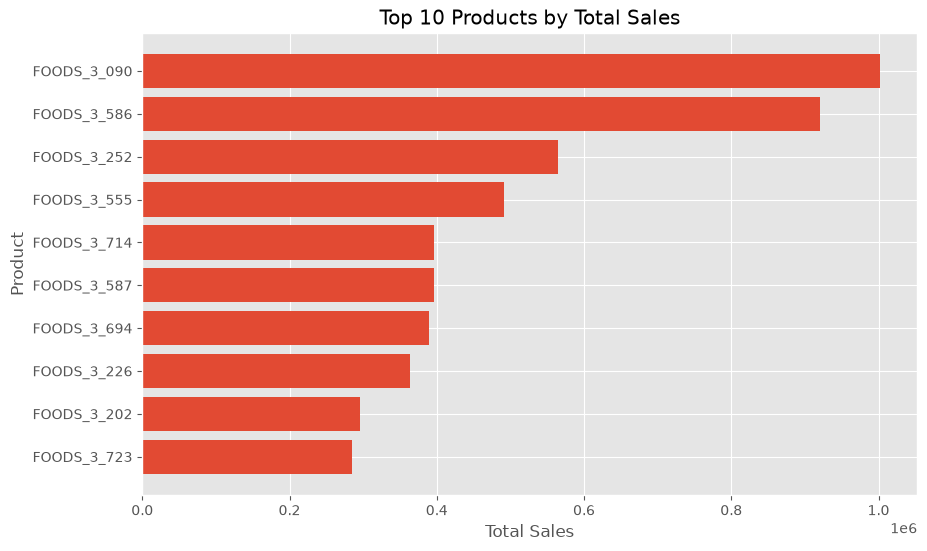

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_products["item_id"],
    top_products["total_sales"]
)

plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.title("Top 10 Products by Total Sales")

plt.gca().invert_yaxis()
plt.show()

In [57]:
top_stores = (
    sales_clean
    .groupby("store_id", as_index=False)["total_sales"]
    .sum()
    .sort_values("total_sales", ascending=False)
    .head(10)
)

top_stores

,store_id,total_sales
2,CA_3,11188180
0,CA_1,7698216
5,TX_2,7214384
8,WI_2,6544012
9,WI_3,6427782
6,TX_3,6089330
1,CA_2,5685475
4,TX_1,5595292
7,WI_1,5149062
3,CA_4,4103676


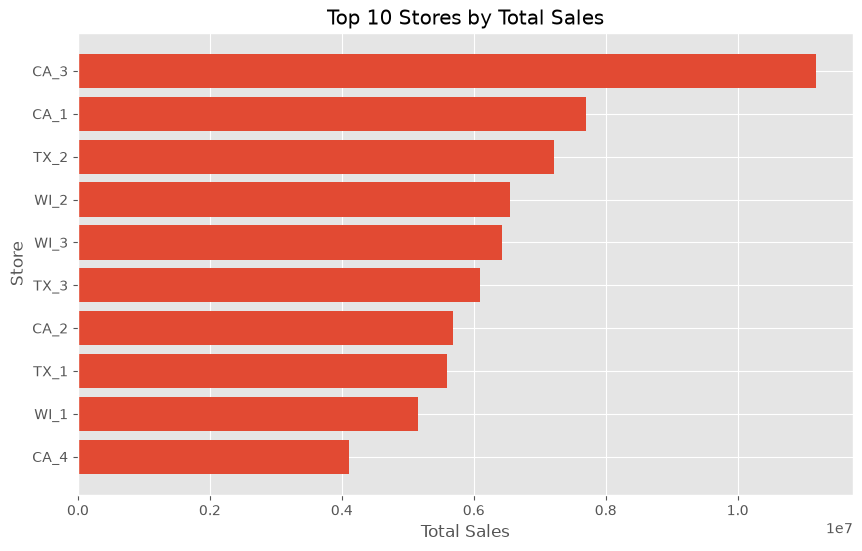

In [58]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_stores["store_id"].astype(str),
    top_stores["total_sales"]
)

plt.xlabel("Total Sales")
plt.ylabel("Store")
plt.title("Top 10 Stores by Total Sales")

plt.gca().invert_yaxis()
plt.show()

In [59]:
regional_sales = sales_clean.groupby(
    "state_id"
)["total_sales"].sum().reset_index()

regional_sales = regional_sales.sort_values(
    by="total_sales",
    ascending=False
)

regional_sales

,state_id,total_sales
0,CA,28675547
1,TX,18899006
2,WI,18120856


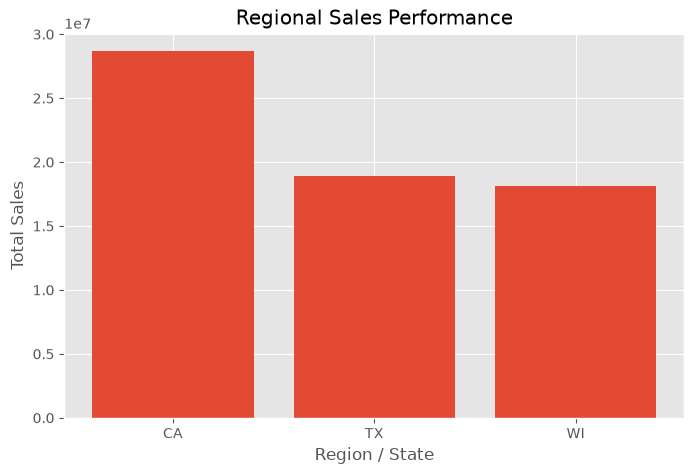

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    regional_sales["state_id"].astype(str),
    regional_sales["total_sales"]
)

plt.title("Regional Sales Performance")
plt.xlabel("Region / State")
plt.ylabel("Total Sales")

plt.show()

In [61]:
sales_clean.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4',
       ...
       'd_1905', 'd_1906', 'd_1907', 'd_1908', 'd_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913', 'total_sales'], dtype='object', length=1920)